# Characterizing a Super-fast Rotating Asteroid in Rubin Observatory First Alerts with Fink 

Let's re-do the analysis of https://iopscience.iop.org/article/10.3847/2515-5172/ae67fe/ampdf.

_Created on 2026/09/28. See https://doc.lsst.fink-broker.org/services/api/solar_system/ for up-to-date documentation._

In [30]:
import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

plt.rcParams.update({"font.size": 15})

import nifty_ls  # noqa: F401
from astropy.time import Time
from astropy.timeseries import LombScargleMultiband
from phunk import PhaseCurve

from sso_utils import plot_lightcurve_allbands

## Object data

Query all data in Fink for the object [2017 QJ216](https://lsst.fink-portal.org/K17QL6J) with its ephemerides:

In [2]:
r = requests.post(
    "https://api.lsst.fink-portal.org/api/v1/sso",
    json={"n_or_d": "2017 QJ216", "withEphem": True, "output-format": "json"},
)

# Format output in a DataFrame
pdf_obj = pd.read_json(io.BytesIO(r.content))

In [3]:
pdf_obj.head(3)

,index,Date,IAU_code,Phase,Elong,RA,DEC,Dobs,RA_h,DEC_h,...,r:trailRaErr,r:trail_flag,r:trail_flag_edge,r:visit,r:x,r:xErr,r:y,r:yErr,f:sso_name,i:magpsf_red
0,0,2.461100e+06,X05,4.595807,168.889631,150.669233,3.676251,1.402627,154.896635,5.511119,...,NaN,NaN,False,2026022700522,3029.9412,0.355364,3268.7507,0.252052,2017 QJ216,18.984646
1,1,2.461100e+06,X05,4.595631,168.890063,150.669351,3.676216,1.402625,154.896523,5.511170,...,NaN,NaN,False,2026022700521,1953.2726,0.353900,2801.7750,0.241011,2017 QJ216,19.116253
2,2,2.461100e+06,X05,4.594704,168.892344,150.669976,3.676030,1.402617,154.895935,5.511440,...,NaN,NaN,False,2026022700519,1567.2805,0.298948,1206.7303,0.334995,2017 QJ216,19.726835


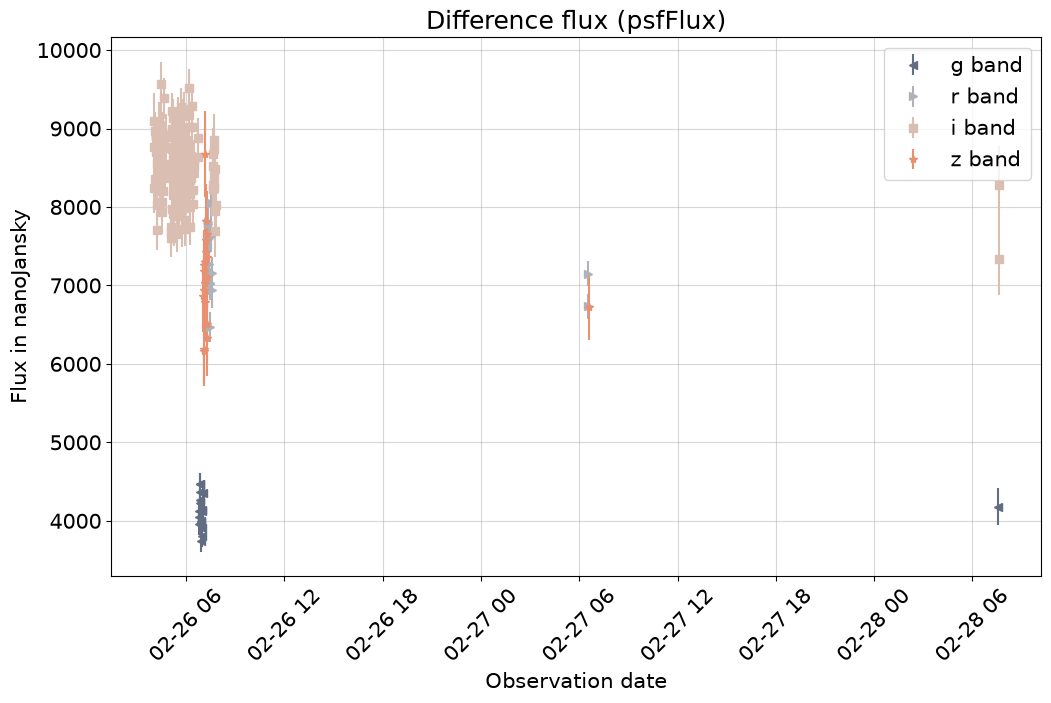

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
plot_lightcurve_allbands(
    pdf_obj["r:midpointMjdTai"],
    pdf_obj["r:psfFlux"],
    pdf_obj["r:psfFluxErr"],
    pdf_obj["r:band"],
    ax=ax,
    label="Difference flux (r band)",
)

ax.grid(alpha=0.5)
ax.legend()
ax.set_ylabel("Flux in nanoJansky")
ax.set_xlabel("Observation date")
ax.set_title("Difference flux (psfFlux)")
plt.xticks(rotation=45)
plt.show()

## Phase curve fitting

These observations are not in the SSOFT, as they have been done in February 2026 (SSOFT data starts on April 2026). So let's fit for the parameters of the HG model using the [space-phunk](https://github.com/astrockers/phunk) package:

In [7]:
def flux_to_mag(flux, flux_err):
    """Convert flux to magnitude (and errors)

    Parameters
    ----------
    flux: array-like
        Flux in nJy
    flux_err: array-like
        Flux error in nJy

    Returns
    -------
    mag, mag_err: array-like
    """
    mag = 31.4 - 2.5 * np.log10(flux)
    mag_err = 2.5 / np.log(10) * flux_err / flux

    return mag, mag_err


# Compute reduced magnitude and error
mag, mag_err = flux_to_mag(pdf_obj["r:scienceFlux"], pdf_obj["r:scienceFluxErr"])
red_mag = mag - 5 * np.log10(pdf_obj["Dobs"] * pdf_obj["Dhelio"])

pc = PhaseCurve(
    phase=pdf_obj["Phase"],
    mag=red_mag,
    mag_err=mag_err,
    epoch=Time(pdf_obj["r:midpointMjdTai"], format="mjd", scale="tai").utc.jd,
    band=pdf_obj["r:band"],
    target="2017 QJ216",
)
pc.fit(["HG"])

```{note} i-band analysis only
For simplicity, let's only focus on the i-band measurements for the rest of this demo.
````

In [8]:
pc.HG.Hi, pc.HG.Hi_err

(18.881582076561752, 0.37385556431228795)

In [9]:
mask_band = pdf_obj["r:band"] == "i"
pc_i = pc.HG.eval(pdf_obj["Phase"][mask_band], H=pc.HG.Hi, G=pc.HG.Gi)

## Period fitting from the residuals

In [27]:
model = LombScargleMultiband(
    pdf_obj["r:midpointMjdTai"][mask_band],
    red_mag[mask_band] - pc_i,
    pdf_obj["r:band"][mask_band],
    mag_err[mask_band],
    nterms_base=2,
    nterms_band=1,
)

frequency, power = model.autopower(
    method="fast",
    sb_method="fastnifty_chi2",
    minimum_frequency=1 / 1.2,
    maximum_frequency=1 / 0.0001,
)

In [28]:
freq_maxpower = frequency[np.argmax(power)]

# one or two-peaked solution ??
period = 1 / freq_maxpower

print(f"Period = {period * 24 * 60:.1f} minutes")

Period = 20.3 minutes


## Plot

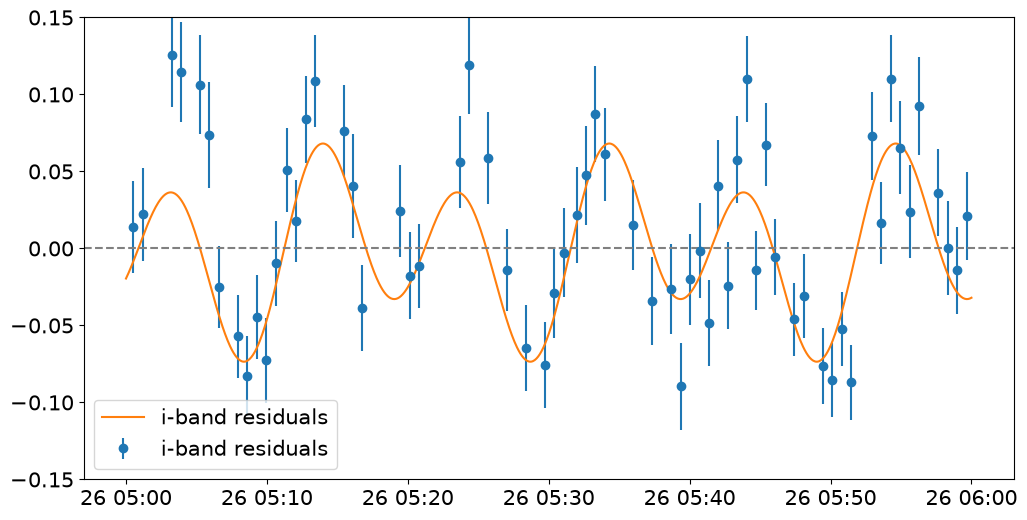

In [29]:
fig = plt.figure(figsize=(12, 6))

# Time boundaries for plots
t0 = Time("2026-02-26 05:00:00").tai.mjd
t1 = Time("2026-02-26 06:00:00").tai.mjd
mask_time = (pdf_obj["r:midpointMjdTai"] >= t0) & (pdf_obj["r:midpointMjdTai"] <= t1)
mask = mask_band & mask_time

tfit_unfolded = np.linspace(
    t0,
    t1,
    # Between 100 and 10000 points, to hopefully have 10 per period
    min(10000, max(1000, int(10 * (t1 - t0) / period))),
)
out_unfolded = model.model(
    tfit_unfolded, freq_maxpower, bands_fit=pdf_obj["r:band"][mask].unique()
)


plt.errorbar(
    Time(pdf_obj["r:midpointMjdTai"], format="mjd", scale="tai").utc.datetime[mask],
    pdf_obj["i:magpsf_red"][mask] - pc_i[mask_time],
    yerr=mag_err[mask],
    ls="",
    marker="o",
    label="i-band residuals",
)
plt.plot(
    Time(tfit_unfolded, format="mjd", scale="tai").utc.datetime,
    out_unfolded[0],
    ls="-",
    marker="",
    label="i-band residuals",
)

plt.axhline(0, ls="--", color="grey")
plt.ylim(-0.15, 0.15)
plt.legend()

````{note} SOCCA
In reality, with sparser cadence and longer baseline, you would use [SOCCA](https://www.aanda.org/articles/aa/abs/2026/09/aa60190-26/aa60190-26.html) to derive the period alongside other phase curve parameters!
````